In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

In [ ]:
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 16),
    nn.ReLU(),

    nn.Linear(16, 8),
    nn.ReLU(),

    nn.Linear(8, 1),
    nn.Sigmoid()
)

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

In [ ]:
epochs = 50
losses = []

for epoch in range(epochs):
    model.train()


    outputs = model(X_train)
    loss = criterion(outputs, y_train)


    optimizer.zero_grad()
    loss.backward()
    optimizer.step()


    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")

Epoch [10/50], Loss: 0.4932
Epoch [20/50], Loss: 0.2043
Epoch [30/50], Loss: 0.0913
Epoch [40/50], Loss: 0.0638
Epoch [50/50], Loss: 0.0484


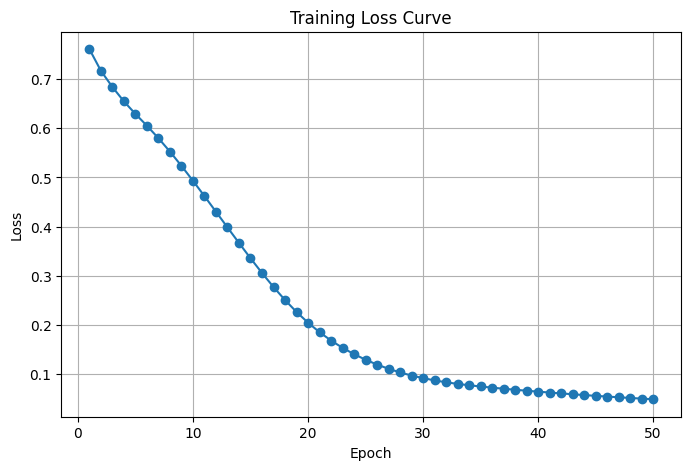

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), losses, marker='o')
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model.eval()

with torch.no_grad():
    predictions = model(X_test)
    predicted = (predictions > 0.5).float()

# Convert to numpy
y_true = y_test.numpy()
y_pred = predicted.numpy()

# Metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"Accuracy : {accuracy * 100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 98.25%
Precision: 0.9859
Recall   : 0.9859
F1 Score : 0.9859
